# Simple Image Classifier — Google Colab Walkthrough

**Lumexa Python & AI Foundations course**

Train a small convolutional neural network (CNN) with TensorFlow/Keras to classify
handwritten digit images (0–9) from the classic MNIST dataset.

This notebook is fully self-contained and works with **Runtime → Run all** — no setup
and no API keys. TensorFlow is preinstalled in Google Colab, and MNIST is downloaded
automatically by Keras the first time it's needed (cached afterward).

**What you'll do:**
1. Load and preprocess the MNIST dataset
2. Build a small CNN
3. Train it for a few epochs (fast on Colab's CPU, faster still on a GPU runtime)
4. Evaluate accuracy on a held-out test set
5. Run inference on a single sample image and display the prediction


In [1]:
# TensorFlow, NumPy, and Matplotlib are preinstalled in Google Colab.
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

%matplotlib inline
print("TensorFlow version:", __import__("tensorflow").__version__)

I0000 00:00:1789672084.398097     870 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789672084.437342     870 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789672085.693109     870 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0


## Step 1: Load and preprocess the MNIST dataset

- Pixel values are normalized from the raw `0-255` range to `0.0-1.0` (helps the network
  train faster and more reliably).
- Each 28x28 grayscale image gets an explicit channel dimension, `(28, 28, 1)`, since
  convolutional layers expect a channel axis even for grayscale images.

In [2]:
NUM_CLASSES = 10
IMAGE_SHAPE = (28, 28, 1)

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print(f"Training images: {X_train.shape}")
print(f"Test images: {X_test.shape}")
print(f"Pixel value range: [{X_train.min():.2f}, {X_train.max():.2f}]")

       0/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

  180224/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

  548864/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

 1417216/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

 3448832/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 7315456/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11436032/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Training images: (60000, 28, 28, 1)
Test images: (10000, 28, 28, 1)
Pixel value range: [0.00, 1.00]


## Step 2: Look at a few sample digits

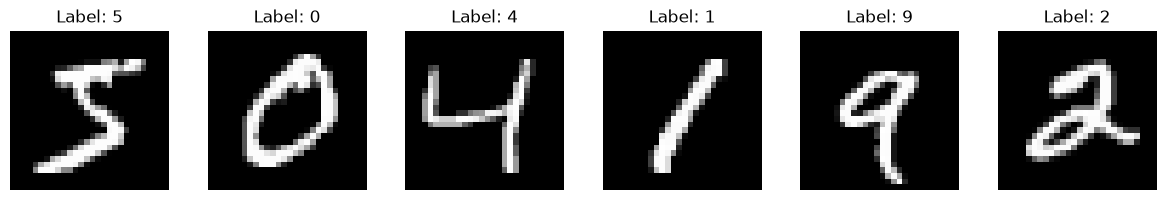

In [3]:
fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i].squeeze(), cmap="gray")
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 3: Define a small CNN

Architecture: `Conv2D(16) -> MaxPooling -> Conv2D(32) -> MaxPooling -> Flatten ->
Dense(64) -> Dropout -> Dense(10, softmax)`.

In [4]:
model = keras.Sequential(
    [
        keras.Input(shape=IMAGE_SHAPE),
        layers.Conv2D(16, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="lumexa_digit_classifier",
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "lumexa_digit_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,714 (221.54 KB)

 Trainable params: 56,714 (221.54 KB)

 Non-trainable params: 0 (0.00 B)

## Step 4: Train the model

Kept small (5 epochs) so it trains quickly on a CPU-only Colab runtime.

In [5]:
EPOCHS = 5
BATCH_SIZE = 64
VALIDATION_SPLIT = 0.1

history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=2,
)

final_train_acc = history.history["accuracy"][-1]
final_val_acc = history.history["val_accuracy"][-1]
print(f"\nFinal training accuracy: {final_train_acc:.4f}")
print(f"Final validation accuracy: {final_val_acc:.4f}")

Epoch 1/5


844/844 - 5s - 6ms/step - accuracy: 0.8888 - loss: 0.3565 - val_accuracy: 0.9758 - val_loss: 0.0810


Epoch 2/5


844/844 - 4s - 5ms/step - accuracy: 0.9630 - loss: 0.1233 - val_accuracy: 0.9833 - val_loss: 0.0550


Epoch 3/5


...

Epoch 4/5


844/844 - 4s - 5ms/step - accuracy: 0.9774 - loss: 0.0753 - val_accuracy: 0.9880 - val_loss: 0.0425


Epoch 5/5


844/844 - 4s - 5ms/step - accuracy: 0.9801 - loss: 0.0643 - val_accuracy: 0.9895 - val_loss: 0.0420



Final training accuracy: 0.9801
Final validation accuracy: 0.9895


## Step 5: Evaluate on the held-out test set

In [6]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.1f}%)")

probabilities = model.predict(X_test, verbose=0)
predicted_labels = np.argmax(probabilities, axis=1)

print(f"\n{'Digit':<8}{'Accuracy':>12}{'Test Count':>14}")
for digit in range(NUM_CLASSES):
    mask = y_test == digit
    count = int(mask.sum())
    correct = int((predicted_labels[mask] == digit).sum())
    accuracy = correct / count if count else 0.0
    print(f"{digit:<8}{accuracy * 100:>11.1f}%{count:>14}")

misclassified = int((predicted_labels != y_test).sum())
print(f"\nTotal misclassified images: {misclassified} out of {len(y_test)}")

Test loss: 0.0386
Test accuracy: 0.9871 (98.7%)



Digit       Accuracy    Test Count
0              99.2%           980
1              99.3%          1135
2              99.2%          1032
3              98.7%          1010
4              97.9%           982
5              98.4%           892
6              98.5%           958
7              98.9%          1028
8              98.4%           974
9              98.4%          1009

Total misclassified images: 129 out of 10000


## Step 6: Classify a single sample image

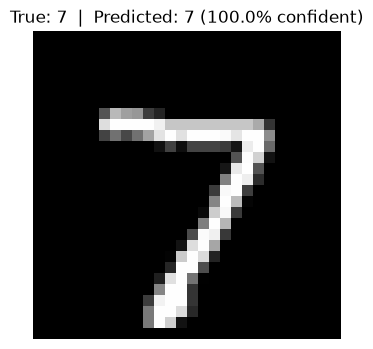

Full probability breakdown:
  digit 0:   0.0%
  digit 1:   0.0%
  digit 2:   0.0%
  digit 3:   0.0%
  digit 4:   0.0%
  digit 5:   0.0%
  digit 6:   0.0%
  digit 7: 100.0%
  digit 8:   0.0%
  digit 9:   0.0%


In [7]:
def predict_single_image(model, image):
    batch = np.expand_dims(image, axis=0)
    probs = model.predict(batch, verbose=0)[0]
    predicted_digit = int(np.argmax(probs))
    confidence = float(probs[predicted_digit])
    return predicted_digit, confidence, probs


SAMPLE_INDEX = 0
image = X_test[SAMPLE_INDEX]
true_label = int(y_test[SAMPLE_INDEX])
predicted_digit, confidence, probabilities = predict_single_image(model, image)

plt.figure(figsize=(4, 4))
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"True: {true_label}  |  Predicted: {predicted_digit} ({confidence * 100:.1f}% confident)")
plt.axis("off")
plt.show()

print("Full probability breakdown:")
for digit, probability in enumerate(probabilities):
    print(f"  digit {digit}: {probability * 100:5.1f}%")

## Summary

This notebook covered a complete, real, end-to-end supervised deep learning
(classification) workflow: loading and preprocessing image data, building a small CNN,
training it, evaluating accuracy on unseen test data, and running inference on a
single new image.

**Try it yourself:** change `SAMPLE_INDEX` above to any value from 0-9999 to classify
a different test image, or increase `EPOCHS` in Step 4 and re-run (`Runtime → Run all`)
to see how training longer affects accuracy.